In [1]:
import numpy as np, matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib
import corner
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk') 
sns.set(font_scale=2)
sns.set_palette('colorblind')
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Times New Roman'

cmap = plt.get_cmap("rainbow_r"); colors = [cmap(i) for i in np.linspace(0, 1, 5)]

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 2   # thickness of the plot box
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1

mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5



In [2]:
import BaryonForge as bfg
import pyccl as ccl
from astropy.cosmology import Planck18 as cosmo
from scipy.integrate import cumulative_trapezoid, simpson
from astropy import constants as con
import os

# importing the following to easily use f_diffuse function defined in mcmc_funcs_vectorized
os.environ["PK_MODEL"] = "BCEmu7_high_z"
os.environ["METHOD"] = "exact"
os.environ["N_FRB"]    = "100"
os.environ["N_PARAMS"] = "1"
from mcmc_funcs import *

from sensitivity_funcs import *

G = con.G.cgs.value
m_p = con.m_p.cgs.value
c = con.c.cgs.value
pc = con.pc.cgs.value; Mpc = 1e6*pc
chi_e = 1 - (0.2453 / 2)
            

class AngularPowerSpectrumCalculator:
    def __init__(self, cosmo_calc, logMmin, logMmax, logMmid):
        self.cosmo = cosmo_calc
        self.logMmin = logMmin
        self.logMmax = logMmax
        self.logMmid = logMmid
        k_fields = np.geomspace(1e-4, 100, 1000); self.k_fields = k_fields
        
        self.get_power_spectra({"log_Mc": 14}, Pk_model="BCEmu1", log10M_max=self.logMmax, log10M_min=self.logMmin, log10M_mid=self.logMmid)
        
    
    def modified_SPk_BCEmu1(self, log_Mc, log10M_max=16, log10M_min=6, log10M_mid=9):
        Ob0 = self.cosmo.Ob0
        Om0 = self.cosmo.Om0

        fft_precision = dict(padding_lo_fftlog = 1e-8, padding_hi_fftlog = 1e8, n_per_decade = 100)
        h = self.cosmo.H0/(1e5/Mpc)/100
        
        ccl_cosmo = ccl.Cosmology(Omega_c = Om0-Ob0, 
                                  Omega_b = Ob0, 
                                  h = h,
                                  sigma8 = 0.8111, 
                                  n_s = 0.9665, 
                                  matter_power_spectrum='linear'
                                 )

        z = 0
        rho  = ccl.rho_x(ccl_cosmo, 1/(1+z), 'matter', is_comoving = True)
        par = dict(theta_ej = 3.5, theta_co = 0.1, M_c = (10**log_Mc)/h, mu_beta = 1, eta = 0.2, eta_delta = 0.2, 
                   tau = -1.5, tau_delta = 0, A = 0.09/2, M1 = 2.5e11/h, epsilon_h = 0.015, 
                   a = 0.3, n = 2, epsilon = 4, p = 0.3, q = 0.707, gamma = 2.5, delta = 7)

        DMO = bfg.Profiles.Schneider19.DarkMatter(**par, r_min_int = 1e-3, r_max_int = 1e2, r_steps = 500)
        GAS = bfg.Profiles.Schneider19.Gas(**par, r_min_int = 1e-3, r_max_int = 1e2, r_steps = 500)
        STR = bfg.Profiles.Schneider19.Stars(**par, r_min_int = 1e-6, r_max_int = 5, r_steps = 500)
        CLM = bfg.Profiles.Schneider19.CollisionlessMatter(**par, max_iter = 2, reltol = 5e-2, r_steps = 500)
        DMB = bfg.Profiles.Schneider19.DarkMatterBaryon(**par, gas = GAS, stars = STR, collisionlessmatter = CLM, darkmatter = DMO, 
                                                        twohalo = bfg.Profiles.misc.Zeros(), r_steps = 500)
        
        M_2_Mtot = bfg.Profiles.misc.Mdelta_to_Mtot(DMO, r_min = 1e-6, r_max = 1e2, N_int = 100)
        GAS = GAS / (rho*Ob0/Om0); DMO = DMO / rho; DMB = DMB / rho
        T   = bfg.Profiles.misc.Truncation(epsilon_trunc = 100)
        GAS = GAS * T; DMO = DMO * T; DMB = DMB * T
        
        for p in [GAS, DMO, DMB]: p.update_precision_fftlog(**fft_precision)
        HMC_flex = HMCalculator_NoCorrection(mass_function = 'Tinker08', halo_bias = 'Tinker10', 
                                             mass_def = ccl.halos.massdef.MassDef200c, 
                                             log10M_min = log10M_min, log10M_max = log10M_mid, nM = 100)
        P_DMO_num = ccl.halos.pk_2pt.halomod_power_spectrum(ccl_cosmo, HMC_flex, self.k_fields, 1/(1+z), DMO, suppress_1h = lambda k : 1e-2, get_2h=False)
        
        HMC_flex = HMCalculator_NoCorrection(mass_function = 'Tinker08', halo_bias = 'Tinker10', 
                                             mass_def = ccl.halos.massdef.MassDef200c, 
                                             log10M_min = log10M_min, log10M_max = log10M_max, nM = 100)
        P_DMO_denom = ccl.halos.pk_2pt.halomod_power_spectrum(ccl_cosmo, HMC_flex, self.k_fields, 1/(1+z), DMO, suppress_1h = lambda k : 1e-2, get_2h=False)
        
        HMC_flex = HMCalculator_NoCorrection(mass_function = 'Tinker08', halo_bias = 'Tinker10', 
                                             mass_def = ccl.halos.massdef.MassDef200c, 
                                             log10M_min = log10M_mid, log10M_max = log10M_max, nM = 100)
        P_DMB_num = ccl.halos.pk_2pt.halomod_power_spectrum(ccl_cosmo, HMC_flex, self.k_fields, 1/(1+z), DMB, suppress_1h = lambda k : 1e-2, get_2h=False)
        
        return (P_DMO_num+P_DMB_num)/P_DMO_denom
    
    
    def modified_Pgas_BCEmu1(self, log_Mc, log10M_max=16, log10M_min=6, log10M_mid=13):
        z_arr = [0]
        Ob0 = self.cosmo.Ob0
        Om0 = self.cosmo.Om0

        fft_precision = dict(padding_lo_fftlog = 1e-8, padding_hi_fftlog = 1e8, n_per_decade = 500)
        h = self.cosmo.H0/(1e5/Mpc)/100
        
        ccl_cosmo = ccl.Cosmology(Omega_c = Om0-Ob0, 
                                  Omega_b = Ob0, 
                                  h = h,
                                  sigma8 = 0.8111, 
                                  n_s = 0.9665, 
                                  matter_power_spectrum='linear'
                                 )

        P_GAS = []
        for z in z_arr:
            rho  = ccl.rho_x(ccl_cosmo, 1/(1+z), 'matter', is_comoving = True)
            par = dict(theta_ej = 3.5, theta_co = 0.1, M_c = (10**log_Mc)/h, mu_beta = 1, eta = 0.2, eta_delta = 0.2, 
                       tau = -1.5, tau_delta = 0, A = 0.09/2, M1 = 2.5e11/h, epsilon_h = 0.015, 
                       a = 0.3, n = 2, epsilon = 4, p = 0.3, q = 0.707, gamma = 2.5, delta = 7)

            DMO = bfg.Profiles.Schneider19.DarkMatter(**par, r_min_int = 1e-3, r_max_int = 1e2, r_steps = 500)
            GAS = bfg.Profiles.Schneider19.Gas(**par, r_min_int = 1e-3, r_max_int = 1e2, r_steps = 500)
            M_2_Mtot = bfg.Profiles.misc.Mdelta_to_Mtot(DMO, r_min = 1e-6, r_max = 1e2, N_int = 100)
            GAS = GAS / (rho*Ob0/Om0)
            T   = bfg.Profiles.misc.Truncation(epsilon_trunc = 100)
            GAS = GAS * T
            for p in [GAS]: p.update_precision_fftlog(**fft_precision)
            HMC_flex = HMCalculator_NoCorrection(mass_function = 'Tinker08', halo_bias = 'Tinker10', 
                                                 mass_def = ccl.halos.massdef.MassDef200c, 
                                                 log10M_min = log10M_mid, log10M_max = log10M_max, nM = 100)

            P_GAS.append(ccl.halos.pk_2pt.halomod_power_spectrum(ccl_cosmo, HMC_flex, self.k_fields, 1/(1+z), GAS, suppress_1h = lambda k : 1e-2, get_2h=False))
            
        return np.array(P_GAS)
    
    
    def get_power_spectra(self, fp, Pk_model, log10M_max=16, log10M_min=6, log10M_mid=9):
        if Pk_model == "BCEmu1":
            Pk_fields = self.modified_SPk_BCEmu1(fp["log_Mc"], log10M_max, log10M_min, log10M_mid)
        else:
            raise ValueError("Unknown Pk_model!")
        self.Pk_fields = Pk_fields
    


Not using emulators.
Unknown Pk_model!


In [3]:
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
from colossus.cosmology import cosmology
from colossus.halo import mass_defs
cosmology.setCosmology("planck18")

def convert_500c_to_200c(logM, z):
    """Convert log10(M500c) -> log10(M200c)."""
    M200, _, _ = mass_defs.changeMassDefinition(
        M=10**logM,
        z=z,
        mdef_in="500c",
        mdef_out="200c",
        c=3,
    )
    return np.log10(M200)


def plot_contour(ax, X, Y, Z, levels, color, label=None,
                 linestyle="--", alpha=0.3, linewidth=1.5):
    """Standardized contour + filled contour + legend patch."""
    ax.contour(X, Y, Z,
               levels=levels,
               colors=color,
               linewidths=linewidth,
               linestyles=linestyle)

    ax.contourf(X, Y, Z,
                levels=levels,
                colors=color,
                alpha=alpha)

    if label is not None:
        ax.fill_between([], [], [],
                        color=color,
                        alpha=0.75,
                        label=label)


def load_sensitivity_block(prefix):
    """Load X, Y, Z, levels from disk."""
    levels = np.load(f"{prefix}_levels.npy")
    X = np.load(f"{prefix}_X.npy")
    Y = np.load(f"{prefix}_Y.npy")
    Z = np.load(f"{prefix}_Z.npy")
    return X, Y, Z, levels



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:20<00:00,  1.26s/it]


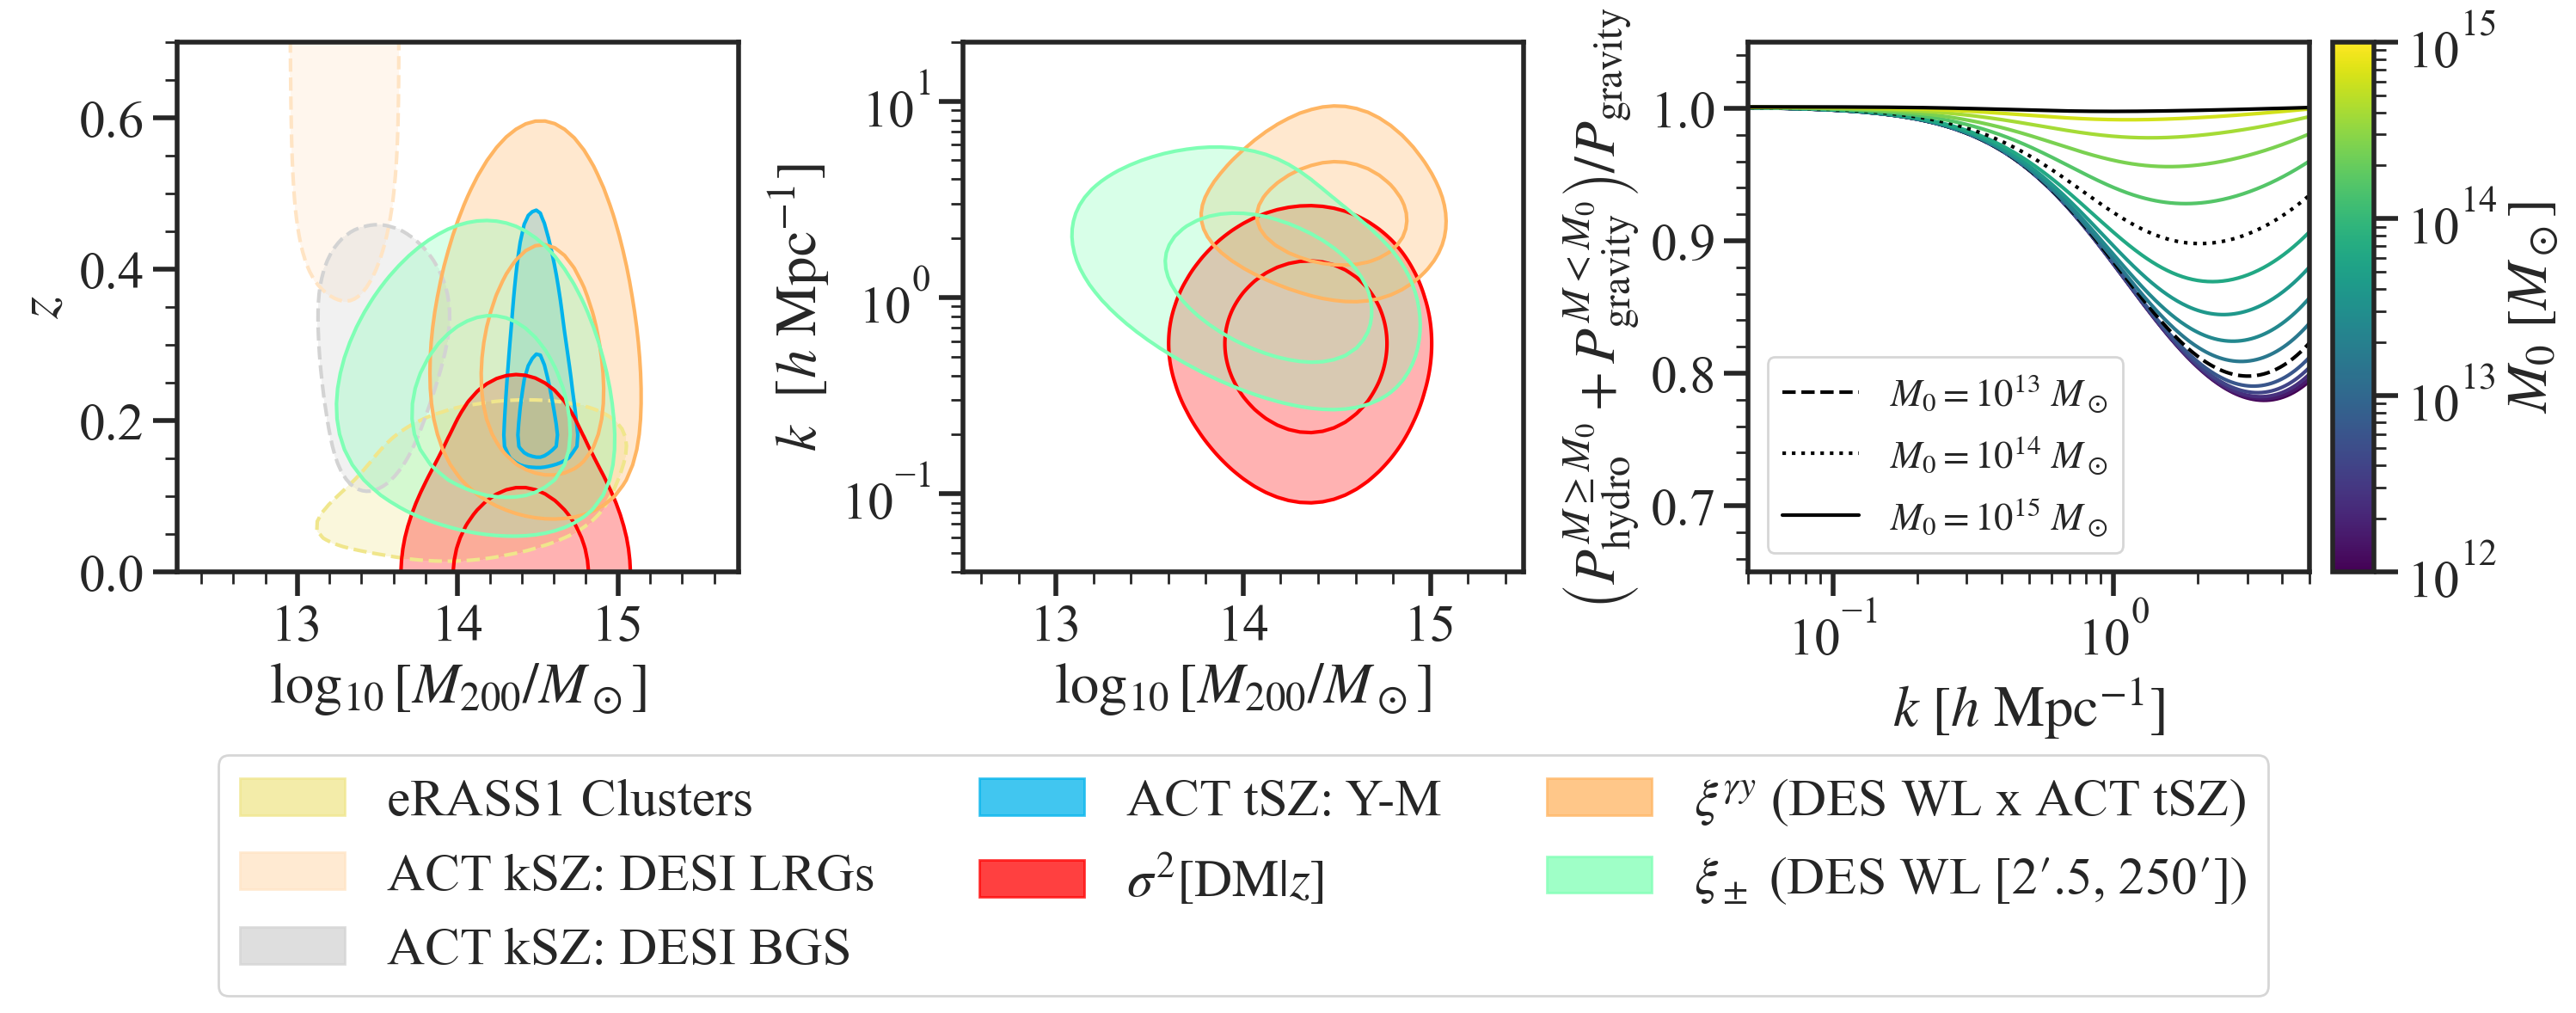

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
plt.subplots_adjust(wspace=0.4)


# ============================================================
# External Constraints (eROSITA, kSZ)
# ============================================================
external_datasets = [
    ("data/sensitivity/siegel2025/erosita", "khaki", "eRASS1 Clusters"),
    ("data/sensitivity/siegel2025/lrg", "bisque", "ACT kSZ: DESI LRGs"),
    ("data/sensitivity/siegel2025/bgs", "lightgray", "ACT kSZ: DESI BGS"),
]

for prefix, color, label in external_datasets:
    X, Y, Z, levels = load_sensitivity_block(prefix)
    X = [convert_500c_to_200c(X[i, :], Y[0, i]) for i in range(len(Y))]
    plot_contour(ax1, X, Y, Z, levels, color, label)

# ============================================================
# Y–M Sensitivity (ACT tSZ)
# ============================================================
YM = np.load("data/sensitivity/YM_sensitivity.npy")

mass = YM["mass"]
redshift = YM["redshift"]
S = YM["sensitivity"]
S[np.isnan(S)] = 1e-300

mass200, _, _ = mass_defs.changeMassDefinition(
    M=mass,
    z=0,
    mdef_in="500c",
    mdef_out="200c",
    c=3,
)

logM_unique = np.log10(np.unique(mass200))
z_unique = np.unique(redshift)

S = S.reshape(len(logM_unique), len(z_unique))
S /= np.max(S)

interp = RegularGridInterpolator(
    (z_unique, logM_unique),
    S.T,
    bounds_error=False,
    fill_value=0.0,
)

logM_fine = np.linspace(logM_unique.min(), logM_unique.max(), 200)
z_fine = np.linspace(z_unique.min(), z_unique.max(), 200)

M_fine, Z_fine = np.meshgrid(logM_fine, z_fine)
points = np.stack([Z_fine.ravel(), M_fine.ravel()], axis=-1)

S_fine = interp(points).reshape(Z_fine.shape)
S_fine[Z_fine < 0.15] = 0
S_fine = gaussian_filter(S_fine, 1)

levels_YM = np.array([0.33, 0.66, 10])
plot_contour(ax1, M_fine, Z_fine, S_fine,
             levels_YM, colors[3], "ACT tSZ: Y-M", linestyle="-")

# ============================================================
# Current FRBs + DES
# ============================================================
files = [
    "data/sensitivity/sensitivity_currentFRBs_DMvar_{}.npy",
    "data/sensitivity/sensitivity_DES_ACT_xi_{}.npy",
    "data/sensitivity/sensitivity_DES_xi_pm_{}.npy",
]

labels = [
    r"$\sigma^2[\mathrm{DM}|z]$",
    r"$\xi^{\gamma y}$ (DES WL x ACT tSZ)",
    r"$\xi_\pm$ (DES WL [2$\prime$.5, 250$\prime$])",
]

levels_current = np.array([0.33, 0.66, 1])

for idx, file_template in enumerate(files):

    # M–z panel
    Z, M, sensitivity = np.load(file_template.format("MZ"))
    sensitivity = gaussian_filter(sensitivity, 2)

    plot_contour(ax1, M, Z, sensitivity,
                 levels_current,
                 colors[idx],
                 labels[idx],
                 linestyle="-")

    # M–k panel
    K, M, sensitivity = np.load(file_template.format("MK"))

    ax2.contour(M, K/(cosmo.H0/100), sensitivity,
                levels=levels_current,
                colors=colors[idx],
                linewidths=1.5)

    ax2.contourf(M, K/(cosmo.H0/100), sensitivity,
                 levels=levels_current,
                 colors=colors[idx],
                 alpha=0.3)

ax1.set(
    xlim=(12.25, 15.75),
    ylim=(0.0, 0.7),
    xlabel=r"$\log_{10} [M_{200}/M_\odot]$",
    ylabel=r"$z$",
)
ax1.legend(loc="lower center", ncol=3, bbox_to_anchor=(1.9, -0.85))
ax1.xaxis.set_major_locator(plt.MultipleLocator(1))
ax1.xaxis.set_minor_locator(plt.MultipleLocator(0.2))
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax1.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

ax2.set(
    xlim=(12.5, 15.5),
    ylim=(4e-2, 20),
    yscale="log",
    xlabel=r"$\log_{10} [M_{200}/M_\odot]$",
    ylabel=r"$k$  [$h~\mathrm{Mpc}^{-1}]$",
)


ax2.xaxis.set_major_locator(plt.MultipleLocator(1))
ax2.xaxis.set_minor_locator(plt.MultipleLocator(0.2))
ax2.set_xlim(12.5, 15.5)
ax2.set_ylim(4e-2, 20)
ax2.set_xlabel(r"$\log_{10} [M_{200}/M_\odot]$")
ax2.set_ylabel(r"$k$  [$h~\mathrm{Mpc}^{-1}]$")
ax2.set_yscale("log")


from astropy.cosmology import Planck18 as cosmo
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=1e12, vmax=10**15)
cmap = cm.viridis


H0 = cosmo.H0.cgs.value; Ob0 = cosmo.Ob0; Om0 = cosmo.Om0; f_d = 0.9
cosmo_calc = CosmologyCalculator(H0, Ob0, Om0, f_d)

for i in tqdm(range(16)):
    logMmid = np.linspace(12, 15, 16)[i]
    aps = AngularPowerSpectrumCalculator(cosmo_calc, 6, 16, logMmid) 
    if ((logMmid != 13) and (logMmid != 14) and (logMmid != 15)):
        ax3.plot(aps.k_fields, aps.Pk_fields, color=cmap(norm(10**logMmid)))
    elif logMmid == 13:
        ax3.plot(aps.k_fields, aps.Pk_fields, color="black", ls="--", label=r"$M_0 = 10^{13}~M_\odot$")
    elif logMmid == 14:
        ax3.plot(aps.k_fields, aps.Pk_fields, color="black", ls="dotted", label=r"$M_0 = 10^{14}~M_\odot$")
    else:
        ax3.plot(aps.k_fields, aps.Pk_fields, color="black", ls="solid", label=r"$M_0 = 10^{15}~M_\odot$")

ax3.legend(fontsize=16)
ax3.set_xscale("log")
ax3.set_xlim(0.05, 5)
ax3.set_ylim(0.65, 1.05)
ax3.set_xlabel(r"$k~[h~\mathrm{Mpc}^{-1}]$")
ax3.set_ylabel(r"${\left(P^{M\geq M_0}_\mathrm{hydro} + P^{M < M_0}_\mathrm{gravity}\right)}/{P_\mathrm{gravity}}$")
ax3.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax3.yaxis.set_minor_locator(plt.MultipleLocator(0.02))

sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
box = ax3.get_position()
ax3.set_position([box.x0*1.0, box.y0, box.width, box.height])
cbar_ax = plt.axes([box.x0*1.0005 + box.width * 1.04, box.y0, 0.015, box.height])
cbar = fig.colorbar(sm, cax=cbar_ax, label=r"$M_0~[M_\odot]$")

plt.savefig('figures/sensitivity_analysis.pdf', dpi=400, bbox_inches='tight')

